In [1]:
import numpy as np

**Default Argument Trap**

In [2]:
# BUGGY VERSION
def train_model_buggy(loss_value, history=[]):
    """Train a model (simulated) and track loss history."""
    history.append(loss_value)
    return history

# Run 1
history1 = train_model_buggy(0.5)
print(f"Run 1 history: {history1}")  # [0.5]

# Run 2
history2 = train_model_buggy(0.3)
print(f"Run 2 history: {history2}")  # [0.5, 0.3] — should be [0.3]!

# Run 3
history3 = train_model_buggy(0.1)
print(f"Run 3 history: {history3}")  # [0.5, 0.3, 0.1] — all runs contaminate each other

Run 1 history: [0.5]
Run 2 history: [0.5, 0.3]
Run 3 history: [0.5, 0.3, 0.1]


each run's history contains entries from previous runs

In [3]:
# FIXED VERSION
def train_model_fixed(loss_value, history=None):
    """Train a model (simulated) and track loss history."""
    if history is None:
        history = []
    history.append(loss_value)
    return history

# Run 1
history1 = train_model_fixed(0.5)
print(f"Run 1 history: {history1}")  # [0.5]

# Run 2
history2 = train_model_fixed(0.3)
print(f"Run 2 history: {history2}")  # [0.3] — correct!

# Run 3
history3 = train_model_fixed(0.1)
print(f"Run 3 history: {history3}")  # [0.1] — each run has its own history

Run 1 history: [0.5]
Run 2 history: [0.3]
Run 3 history: [0.1]


Vectorization: Python Vs NumPy

In [4]:
import numpy as np
import time

n = 1_000_000

# Python loop
start = time.time()
python_result = []
for i in range(n):
    python_result.append(i * 2)
python_time = time.time() - start

# NumPy vectorization
start = time.time()
numpy_array = np.arange(n)
numpy_result = numpy_array * 2
numpy_time = time.time() - start

print(f"Python loop: {python_time:.4f} seconds")
print(f"NumPy:       {numpy_time:.4f} seconds")
print(f"Speedup:     {python_time / numpy_time:.1f}×")

Python loop: 0.0674 seconds
NumPy:       0.0083 seconds
Speedup:     8.1×


Real-world Example (with 1M samples and 100 features)

In [5]:
# Python loop (painfully slow)
data = [[i for i in range(100)] for _ in range(1_000_000)]
start = time.time()
standardized = []
for row in data:
    mean = sum(row) / len(row)
    std = (sum((x - mean)**2 for x in row) / len(row)) ** 0.5
    standardized.append([(x - mean) / std for x in row])
print(f"Python: {time.time() - start:.2f} seconds")

# NumPy (instant)
data_np = np.random.randn(1_000_000, 100)
start = time.time()
mean = data_np.mean(axis=0)
std = data_np.std(axis=0)
standardized_np = (data_np - mean) / std
print(f"NumPy: {time.time() - start:.4f} seconds")

Python: 19.33 seconds
NumPy: 1.0273 seconds


Shape Errors
- NumPy broadcasting can make operations succeed when they shouldn't
- scenario: You're building a machine learning model that expects input of shape (batch_size, 10). But you accidentally give it shape (10,)

In [6]:
import numpy as np

# Your model weights: shape (10, 5) meaning 10 input features → 5 output
weights = np.random.randn(10, 5)
print(f"Weights are: {weights}")
print(f"Weights shape: {weights.shape}")

# Correct input: batch of 32 samples, 10 features each
X_correct = np.random.randn(32, 10)
output_correct = X_correct @ weights  # shape (32, 5) ✓
print(f"Correct shape: {output_correct.shape}")

# Buggy input: accidentally 1D
X_buggy = np.random.randn(10)
output_buggy = X_buggy @ weights  # shape (5,) instead of (32, 5)!
print(f"Buggy shape: {output_buggy.shape}")

# Your code doesn't crash. The model "runs" but it's computing nonsense.
print(f"Correct output sample: {output_correct[0]}")
print(f"Buggy output: {output_buggy}")

Weights are: [[ 0.10705761  0.50680116  1.59431432  0.34506335  0.6881478 ]
 [-0.12846401 -0.30317541 -1.62248238  0.86228713 -0.6102272 ]
 [ 0.75538521  0.66909078 -0.9768398  -0.10864963  0.69195773]
 [-1.33957166  0.93176319 -1.07581161 -0.18798757 -0.59597606]
 [ 0.25387878 -0.413635    1.84904194  0.3362181   0.25044461]
 [ 0.1850432   0.18216839  0.02898149 -1.62494856  0.81884488]
 [ 0.49849409 -0.93773923  0.34536856 -1.07609302  0.25384248]
 [ 1.07863652  0.39457249 -0.07805764  0.00657956 -0.22700946]
 [ 0.40942418 -0.57333916  0.476771    1.05761996  0.62978983]
 [-0.45122743  0.69882511  0.7009815  -1.12514404  1.65570518]]
Weights shape: (10, 5)
Correct shape: (32, 5)
Buggy shape: (5,)
Correct output sample: [-2.90132508  2.47485677 -2.66596025  1.34271842 -0.82707074]
Buggy output: [ 2.74508018 -0.11889119 -1.57334404 -0.06248076 -1.22502073]


In [7]:
def forward_pass(X, weights):
    assert X.shape[1] == weights.shape[0], f"Shape mismatch: X.shape={X.shape}, weights.shape={weights.shape}"
    return X @ weights

# Now the buggy case raises an assertion error and you see it immediately
X_buggy = np.random.randn(10)
output = forward_pass(X_buggy, weights)  # AssertionError!

IndexError: tuple index out of range

Dot Product: Measuring Similarity

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define vectors
same_direction = np.array([1, 0, 0])
perpendicular = np.array([0, 1, 0])
opposite = np.array([-1, 0, 0])
similar_but_diff_magnitude = np.array([2, 0, 0])

base = np.array([1, 0, 0])

# Compute dot products
print("Dot products with [1, 0, 0]:")
print(f"  vs [1, 0, 0] (same direction): {base @ same_direction}")
print(f"  vs [0, 1, 0] (perpendicular): {base @ perpendicular}")
print(f"  vs [-1, 0, 0] (opposite): {base @ opposite}")
print(f"  vs [2, 0, 0] (same dir, diff magnitude): {base @ similar_but_diff_magnitude}")

# Normalize to unit vectors for pure direction similarity
normalized_base = base / np.linalg.norm(base)
normalized_same = same_direction / np.linalg.norm(same_direction)
normalized_opposite = opposite / np.linalg.norm(opposite)
normalized_perp = perpendicular / np.linalg.norm(perpendicular)

print("\nDot products with normalized vectors (cosine similarity):")
print(f"  vs [1, 0, 0]: {normalized_base @ normalized_same:.4f}")
print(f"  vs [-1, 0, 0]: {normalized_base @ normalized_opposite:.4f}")
print(f"  vs [0, 1, 0]: {normalized_base @ normalized_perp:.4f}")

Dot products with [1, 0, 0]:
  vs [1, 0, 0] (same direction): 1
  vs [0, 1, 0] (perpendicular): 0
  vs [-1, 0, 0] (opposite): -1
  vs [2, 0, 0] (same dir, diff magnitude): 2

Dot products with normalized vectors (cosine similarity):
  vs [1, 0, 0]: 1.0000
  vs [-1, 0, 0]: -1.0000
  vs [0, 1, 0]: 0.0000


Real World Example: Embedding similarity on Recommender Systems

In [13]:
# Embeddings for movies (learned from data)
movie_a_embedding = np.array([0.5, 0.2, 0.8, 0.1])  # Drama, slow, emotional
movie_b_embedding = np.array([0.6, 0.1, 0.7, 0.2])  # Similar drama
movie_c_embedding = np.array([0.9, 0.8, 0.1, 0.9])  # Action, fast, loud

# Normalize for cosine similarity
movie_a = movie_a_embedding / np.linalg.norm(movie_a_embedding)
movie_b = movie_b_embedding / np.linalg.norm(movie_b_embedding)
movie_c = movie_c_embedding / np.linalg.norm(movie_c_embedding)

# Similarity between movies
print("Movie similarities:")
print(f"  A vs B: {movie_a @ movie_b:.4f} (similar? yes)")
print(f"  A vs C: {movie_a @ movie_c:.4f} (similar? no)")

# If user watched movie A, recommend B (higher similarity)

Movie similarities:
  A vs B: 0.9785 (similar? yes)
  A vs C: 0.5340 (similar? no)


In [14]:
np.linalg.norm(movie_a_embedding)

np.float64(0.9695359714832659)

In [15]:
movie_a_embedding / np.linalg.norm(movie_a_embedding)

array([0.51571062, 0.20628425, 0.825137  , 0.10314212])

In [16]:
(movie_a_embedding / np.linalg.norm(movie_a_embedding)) @ (movie_b_embedding / np.linalg.norm(movie_b_embedding))

np.float64(0.9784921095801633)

Gradient Descent: minimize y= (x-3)^2

Step  0: x=8.6000, loss=31.3600
Step  5: x=4.8350, loss=3.3673
Step 10: x=3.6013, loss=0.3616
Step 15: x=3.1970, loss=0.0388
Step 20: x=3.0646, loss=0.0042
Step 25: x=3.0212, loss=0.0004

Final x: 3.0087 (optimal: 3.0000)


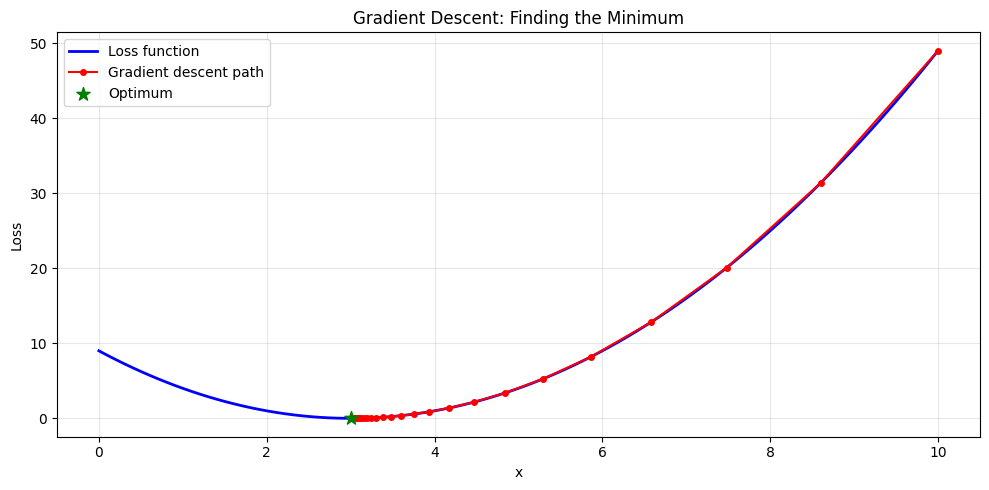

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define loss function: L(x) = (x - 3)^2
def loss(x):
    return (x - 3) ** 2

# Gradient of loss: dL/dx = 2(x - 3)
def gradient(x):
    return 2 * (x - 3)

# Gradient descent
x = 10  # Start far from optimum
learning_rate = 0.1
history = []

for step in range(30):
    grad = gradient(x)
    x_new = x - learning_rate * grad  # Move opposite to gradient
    history.append(x)
    x = x_new
    
    if step % 5 == 0:
        print(f"Step {step:2d}: x={x:.4f}, loss={loss(x):.4f}")

print(f"\nFinal x: {x:.4f} (optimal: 3.0000)")

# Visualize
x_range = np.linspace(0, 10, 100)
plt.figure(figsize=(10, 5))
plt.plot(x_range, loss(x_range), 'b-', linewidth=2, label='Loss function')
plt.plot(history, [loss(x) for x in history], 'ro-', markersize=4, label='Gradient descent path')
plt.scatter([3], [0], color='green', s=100, marker='*', label='Optimum', zorder=5)
plt.xlabel('x')
plt.ylabel('Loss')
plt.title('Gradient Descent: Finding the Minimum')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# What if learning rate is too large?
x = 10
learning_rate = 0.5  # Too large!
history_large = []

for step in range(30):
    grad = gradient(x)
    x = x - learning_rate * grad
    history_large.append(x)
    if step % 5 == 0:
        print(f"Step {step:2d}: x={x:.4f}, loss={loss(x):.4f}")

Step  0: x=3.0000, loss=0.0000
Step  5: x=3.0000, loss=0.0000
Step 10: x=3.0000, loss=0.0000
Step 15: x=3.0000, loss=0.0000
Step 20: x=3.0000, loss=0.0000
Step 25: x=3.0000, loss=0.0000


Type Hints

In [19]:
# --- Cell 6: Type hints in practice ---
import numpy as np
from typing import Optional

# WITHOUT type hints — unclear what goes in and comes out
def compute_metrics(y_true, y_pred, threshold=0.5):
    correct = sum(1 for t, p in zip(y_true, y_pred) if (p >= threshold) == t)
    return correct / len(y_true)

# WITH type hints — completely clear
def compute_metrics_typed(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    threshold: float = 0.5,
) -> float:
    """Compute accuracy at a given decision threshold.

    Args:
        y_true:    Ground-truth binary labels (0 or 1).
        y_pred:    Predicted probabilities for the positive class.
        threshold: Decision threshold. Default 0.5.

    Returns:
        Accuracy as a float in [0, 1].
    """
    predictions = (y_pred >= threshold).astype(int)
    return float((predictions == y_true).mean())

# Test it
y_true = np.array([0, 1, 1, 0, 1])
y_pred = np.array([0.1, 0.9, 0.8, 0.3, 0.6])

print(f"Accuracy at threshold=0.5: {compute_metrics_typed(y_true, y_pred):.2f}")
print(f"Accuracy at threshold=0.7: {compute_metrics_typed(y_true, y_pred, threshold=0.7):.2f}")

Accuracy at threshold=0.5: 1.00
Accuracy at threshold=0.7: 0.80
